In [1]:
import scarf

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name='tenx_8K_pbmc_citeseq',
    save_path='scarf_datasets',
    as_zarr=True
)

ds = scarf.DataStore(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    default_assay='RNA',
    nthreads=4,
)

ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.make_graph(feat_key='hvgs', k=11, dims=15)
ds.run_leiden_clustering(resolution=0.5)
ds.run_umap(n_epochs=100, parallel=False, random_seed=4444)
ds.run_marker_search(group_key='RNA_leiden_cluster', gene_batch_size=100)

ds

DataStore has 7549 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'ADT_nFeatures', 'RNA_tSNE2', 
            'ADT_UMAP2', 'RNA_percentMito', 'RNA_tSNE1', 'ADT_UMAP1', 'RNA_percentRibo', 
            'ADT_nCounts', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'ADT_leiden_cluster', 'RNA_cluster', 'RNA_UMAP1'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__hvgs', 'stats_I_sigmas', 'stats_I_normed_n', 'stats_I_avg', 'stats_I_normed_tot', 
            'stats_I_c_var__200__0.1', 'stats_I_nz_mean'

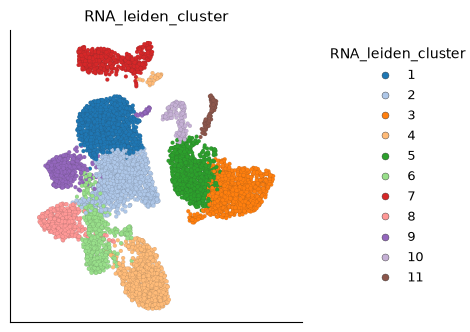

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [4]:
ds.show_zarr_tree(depth=1)

/
├── ADT
│   ├── counts (7865, 17) uint32
│   ├── featureData
│   └── normed__I__I
├── RNA
│   ├── counts (7865, 33538) uint32
│   ├── featureData
│   ├── markers
│   ├── normed__I__hvgs
│   └── summary_stats_I
└── cellData
    ├── ADT_UMAP1 (7865,) float32
    ├── ADT_UMAP2 (7865,) float32
    ├── ADT_leiden_cluster (7865,) int64
    ├── ADT_nCounts (7865,) float64
    ├── ADT_nFeatures (7865,) float64
    ├── I (7865,) bool
    ├── RNA_UMAP1 (7865,) float32
    ├── RNA_UMAP2 (7865,) float32
    ├── RNA_cluster (7865,) int64
    ├── RNA_leiden_cluster (7865,) int64
    ├── RNA_nCounts (7865,) float64
    ├── RNA_nFeatures (7865,) float64
    ├── RNA_percentMito (7865,) float64
    ├── RNA_percentRibo (7865,) float64
    ├── RNA_tSNE1 (7865,) float64
    ├── RNA_tSNE2 (7865,) float64
    ├── ids (7865,) <U18
    └── names (7865,) <U18



In [5]:
ds.show_zarr_tree(start='cellData')

/cellData
├── ADT_UMAP1 (7865,) float32
├── ADT_UMAP2 (7865,) float32
├── ADT_leiden_cluster (7865,) int64
├── ADT_nCounts (7865,) float64
├── ADT_nFeatures (7865,) float64
├── I (7865,) bool
├── RNA_UMAP1 (7865,) float32
├── RNA_UMAP2 (7865,) float32
├── RNA_cluster (7865,) int64
├── RNA_leiden_cluster (7865,) int64
├── RNA_nCounts (7865,) float64
├── RNA_nFeatures (7865,) float64
├── RNA_percentMito (7865,) float64
├── RNA_percentRibo (7865,) float64
├── RNA_tSNE1 (7865,) float64
├── RNA_tSNE2 (7865,) float64
├── ids (7865,) <U18
└── names (7865,) <U18

  ADT_nFeatures: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP2: shape=(7865,), dtype=float32, chunks=(100000,)
  RNA_percentMito: shape=(7865,), dtype=float64, chunks=(100000,)
  RNA_tSNE2: shape=(7865,), dtype=float64, chunks=(100000,)
  RNA_tSNE1: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP1: shape=(7865,), dtype=float32, chunks=(100000,)
  names: shape=(7865,), dtype=<U18, chunks=(100000,)
  I: shape=(786

In [6]:
ds.show_zarr_tree(start='RNA', depth=1)

/RNA
├── counts (7865, 33538) uint32
├── featureData
│   ├── I (33538,) bool
│   ├── I__hvgs (33538,) bool
│   ├── dropOuts (33538,) int64
│   ├── ids (33538,) <U15
│   ├── nCells (33538,) int64
│   └── names (33538,) <U16
├── markers
│   ├── I__RNA_cluster
│   └── I__RNA_leiden_cluster
├── normed__I__hvgs
│   ├── data (7549, 500) float32
│   ├── mu (500,) float64
│   ├── reduction__pca__15__I
│   └── sigma (500,) float64
└── summary_stats_I
    ├── avg (33538,) float64
    ├── c_var__200__0.1 (33538,) float64
    ├── normed_n (33538,) float64
    ├── normed_tot (33538,) float64
    ├── nz_mean (33538,) float64
    └── sigmas (33538,) float64

  counts: shape=(7865, 33538), dtype=uint32, chunks=(2000, 1000)


In [7]:
ds.show_zarr_tree(start='RNA/featureData', depth=1)

/RNA/featureData
├── I (33538,) bool
├── I__hvgs (33538,) bool
├── dropOuts (33538,) int64
├── ids (33538,) <U15
├── nCells (33538,) int64
└── names (33538,) <U16

  names: shape=(33538,), dtype=<U16, chunks=(100000,)
  I: shape=(33538,), dtype=bool, chunks=(100000,)


  I__hvgs: shape=(33538,), dtype=bool, chunks=(100000,)
  nCells: shape=(33538,), dtype=int64, chunks=(100000,)
  ids: shape=(33538,), dtype=<U15, chunks=(100000,)
  dropOuts: shape=(33538,), dtype=int64, chunks=(100000,)


In [8]:
ds.cells.head()

,I,ids,names,ADT_UMAP2,RNA_tSNE2,RNA_percentMito,ADT_nFeatures,ADT_UMAP1,RNA_tSNE1,RNA_percentRibo,ADT_nCounts,RNA_nFeatures,RNA_cluster,RNA_nCounts,RNA_leiden_cluster,RNA_UMAP2,RNA_UMAP1,ADT_leiden_cluster
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,9.510007,-18.08830,8.668831,17.0,-13.884989,-4.26865,15.259740,981.0,2194.0,4,6160.0,3,-9.029472,15.049529,16
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,10.784672,-14.88920,6.316103,17.0,-5.097915,5.02671,19.037688,1475.0,2093.0,4,6713.0,3,-4.521802,17.883667,15
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,12.961405,-18.83030,8.056090,17.0,-7.885502,-14.91320,16.002200,7149.0,1518.0,5,3637.0,3,-4.657635,10.936290,9
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,11.531997,-3.35003,9.003215,17.0,12.072053,16.69630,18.729904,6831.0,737.0,3,1244.0,4,-21.121382,0.024575,2
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,12.290624,-1.37607,6.204519,17.0,13.928782,18.37000,16.353887,6839.0,1240.0,3,2611.0,4,-17.950577,1.193951,2


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts,stats_I_normed_n,stats_I_normed_tot,stats_I_sigmas,stats_I_avg,stats_I_nz_mean,stats_I_c_var__200__0.1
0,False,ENSG00000243485,MIR1302-2HG,0,False,7865,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,False,7865,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,False,7865,NaN,NaN,NaN,NaN,NaN,NaN
3,False,ENSG00000238009,AL627309.1,12,False,7853,NaN,NaN,NaN,NaN,NaN,NaN
4,False,ENSG00000239945,AL627309.3,0,False,7865,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_leiden_cluster']
).set_index('ids')

,RNA_nCounts,RNA_nFeatures,RNA_leiden_cluster
ids,,,
AAACCCAAGATTGTGA-1,6160.0,2194.0,3
AAACCCACATCGGTTA-1,6713.0,2093.0,3
AAACCCAGTACCGCGT-1,3637.0,1518.0,3
AAACCCAGTATCGAAA-1,1244.0,737.0,4
AAACCCAGTCGTCATA-1,2611.0,1240.0,4
...,...,...,...
TTTGTTGGTTCAAGTC-1,5830.0,2178.0,4
TTTGTTGGTTGCATGT-1,4096.0,1256.0,9
TTTGTTGGTTGCGGCT-1,5524.0,1907.0,3


In [11]:
cluster_labels = ds.cells.fetch('RNA_leiden_cluster')
cluster_labels.shape, ds.cells.fetch_all('RNA_leiden_cluster').shape

((7549,), (7865,))

In [12]:
is_cluster_1 = cluster_labels.astype(str) == '1'
ds.cells.insert(column_name='is_cluster_1', values=is_cluster_1, overwrite=True)

In [13]:
ds.cells.insert(
    column_name='is_cluster_1',
    values=is_cluster_1,
)

ValueError: ERROR: is_cluster_1 already exists. Please set `overwrite` to True to overwrite.

In [14]:
ds.RNA.rawData

ChunkedArray(shape=(7865, 33538), dtype=uint32, chunksize=(2000, 33538), numblocks=4)

In [15]:
ds.RNA.normed()

ChunkedArray(shape=(7549, 13550), dtype=float64, chunksize=(2000, 13550), numblocks=4)

In [16]:
import inspect

print(inspect.getsource(ds.RNA.normMethod))

def norm_lib_size(assay: "Assay", counts: ChunkedArray) -> ChunkedArray:
    """Performs library size normalization on the data. This is the default
    method for RNA assays.

    Args:
        assay: An instance of the assay object
        counts: A chunked array with raw counts data

    Returns:  A chunked array (delayed matrix) containing normalized data.
    """
    assert assay.sf is not None and assay.scalar is not None
    return assay.sf * counts / assay.scalar.reshape(-1, 1)



In [17]:
def my_cool_normalization_method(assay, counts):
    import numpy as np

    lib_size = counts.sum(axis=1).reshape(-1, 1)
    return np.log2(counts / lib_size)

ds.RNA.normMethod = my_cool_normalization_method
ds.RNA.normMethod = scarf.assay.norm_dummy

In [18]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore',
        message='Object at ann_idx is not recognized as a component of a Zarr hierarchy.',
    )
    ds.show_zarr_tree(start='RNA/normed__I__hvgs')

/RNA/normed__I__hvgs
├── data (7549, 500) float32
├── mu (500,) float64
├── reduction__pca__15__I
│   ├── ann__l2__50__50__48__4466
│   │   ├── ann_idx_bytes (3503016,) uint8
│   │   └── knn__11
│   ├── kmeans__1000__4466
│   │   ├── cluster_centers (1000, 15) float64
│   │   └── cluster_labels (7549,) float64
│   └── reduction (500, 15) float64
└── sigma (500,) float64

  sigma: shape=(500,), dtype=float64, chunks=(500,)
  data: shape=(7549, 500), dtype=float32, chunks=(7549, 500)
  mu: shape=(500,), dtype=float64, chunks=(500,)


In [19]:
ds.load_graph(
    from_assay='RNA',
    cell_key='I',
    feat_key='hvgs',
    symmetric=False,
    upper_only=False,
)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83039 stored elements and shape (7549, 7549)>

In [20]:
ds.show_zarr_tree(start='RNA/markers', depth=2)

/RNA/markers
├── I__RNA_cluster
│   ├── 1
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 10
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 11
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 12
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) 

In [21]:
ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,NOG,0.53835,0.06256,0.00364,0.16809,0.01454,17.18982,1.158059e-144,11175
1,1,ANKRD55,0.51016,0.03739,0.00273,0.11619,0.01278,13.68610,1.173673e-87,3599
2,1,FHIT,0.50697,0.08223,0.01020,0.23238,0.04235,8.06411,9.395148e-130,2618
3,1,EPHX2,0.50259,0.07782,0.00877,0.22308,0.03484,8.87209,1.258879e-139,5926
4,1,CHRM3-AS2,0.46972,0.10064,0.01330,0.27343,0.04858,7.56614,1.034841e-157,1351


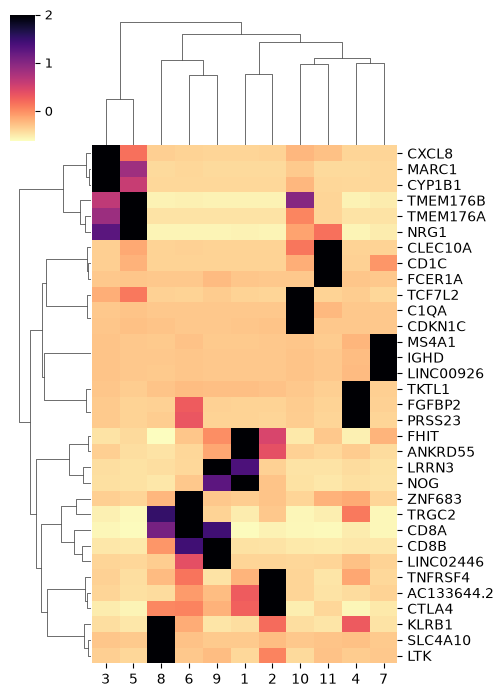

PlotResult(axes=4, tables=2, legends=1, scales=2, owns_figure=True, rendered=True)

In [22]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=3,
    figsize=(5, 7),
)

In [23]:
ds.export_markers_to_csv(
    group_key='RNA_leiden_cluster',
    csv_filename='scarf_datasets/data_organization_markers.csv',
    min_score=0.2,
    min_frac_exp=0.1,
)